In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score
)

In [13]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Class Distribution:")
print(pd.Series(y).value_counts())

Class Distribution:
1    357
0    212
Name: count, dtype: int64


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [17]:
cm = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



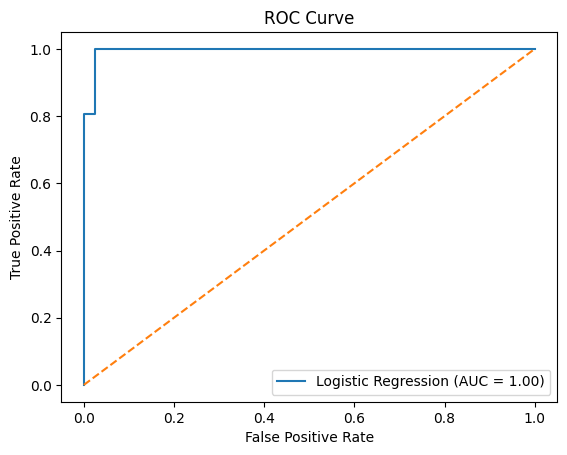

In [18]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.2f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [19]:
log_balanced = LogisticRegression(class_weight="balanced", max_iter=1000)
log_balanced.fit(X_train_scaled, y_train)

y_pred_bal = log_balanced.predict(X_test_scaled)
y_prob_bal = log_balanced.predict_proba(X_test_scaled)[:, 1]

print("\nBalanced Logistic Regression Report:")
print(classification_report(y_test, y_pred_bal))


Balanced Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



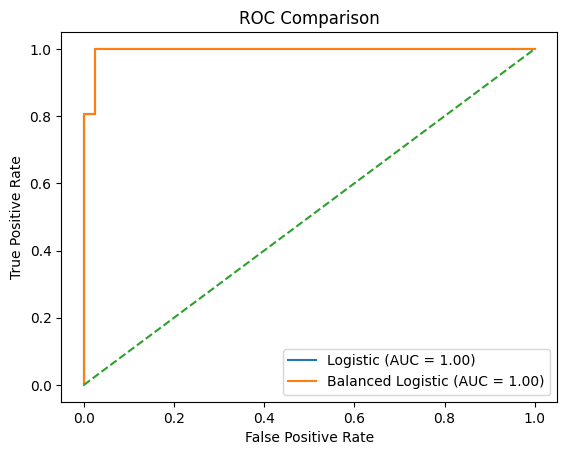

In [20]:
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_prob_bal)
auc_bal = roc_auc_score(y_test, y_prob_bal)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.2f})")
plt.plot(fpr_bal, tpr_bal, label=f"Balanced Logistic (AUC = {auc_bal:.2f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison")
plt.legend()
plt.show()

In [21]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]

print("\nDecision Tree Report:")
print(classification_report(y_test, y_pred_tree))


Decision Tree Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [22]:
print("Tree Train Accuracy:", tree.score(X_train, y_train))
print("Tree Test Accuracy:", tree.score(X_test, y_test))

Tree Train Accuracy: 1.0
Tree Test Accuracy: 0.9122807017543859


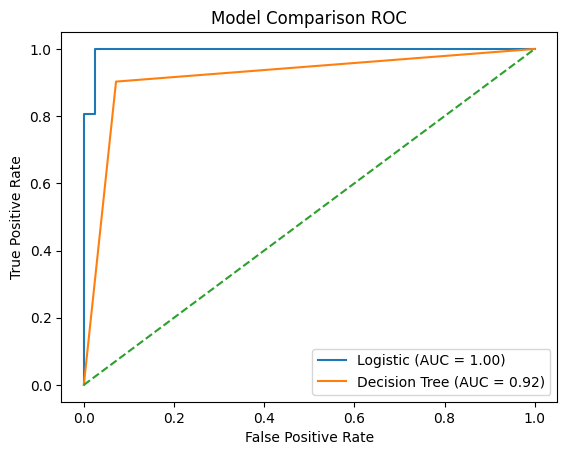

In [23]:
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
auc_tree = roc_auc_score(y_test, y_prob_tree)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.2f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.2f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model Comparison ROC")
plt.legend()
plt.show()

1. Confusion Matrix Explanation
----

    True Positive (TP): Model correctly predicts malignant tumor.

    True Negative (TN): Model correctly predicts benign tumor.

    False Positive (FP): Model predicts malignant but actually benign.
    
    False Negative (FN): Model predicts benign but actually malignant.
    
    In medical diagnosis, False Negatives are dangerous because missing a cancer case may delay treatment.

    Why Accuracy Alone is Insufficient?
    ----

    Accuracy can be misleading in imbalanced datasets.
    If 95% patients are healthy, predicting all as healthy gives 95% accuracy but fails to detect cancer. Therefore, precision, recall, and F1-score are more reliable.

2. Most Important Metric for Medical Diagnosis
----
    Recall is more important because it measures how many actual positive cases were correctly identified.

    If recall is low, many cancer cases will be missed, which can be life-threatening.

    F1-score is preferred for imbalanced data because it balances both precision and recall.

3. Logistic Regression vs Decision Tree
----
    -------------------------------------------------------
    Aspect	          |Logistic Regression	 |Decision Tree
    -------------------------------------------------------
    Stability         |More stable	         |Less stable
    Interpretability  |Moderate	             |High
    Overfitting	      |Less prone	         |High risk
    Pattern Handling  |Linear	             |Non-linear
    ------------------------------------------------------